<a href="https://colab.research.google.com/github/biswaskc57/marketing-trends-and-data-analysing/blob/main/ch1_coca_cola_data_students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Data Generation for Coca-Cola Marketing Mix
**A Step-by-Step Guided Case Study**

## 🥤 Introduction: The Coca-Cola Scenario
Welcome! In this class, you are a Business Analyst at Coca-Cola. You don't need to be a programmer to use this tool. Think of the code cells below as "Engines" that generate a year of sales data for us.


# Step 1. Configuration and Library Installation

Before starting, we need to load our tools. This section sets up the required Python libraries. `Faker` is essential for generating realistic, structured categorical IDs (like Campaign IDs and Market Codes), adding a layer of corporate data complexity.

Just click the "Play" button on the left of the cell below. You don't need to change anything here.

In [103]:
# Just press play!

# Install Faker (if necessary)
!pip3 install pandas numpy faker seaborn matplotlib

# Import libraries
import pandas as pd
import numpy as np
from faker import Faker
import random
import seaborn as sns
import matplotlib.pyplot as plt

random.seed(42)


🤖 **Meet "Faker": Our Digital Reality Generator**

In the business world, we often face a problem: Real data is sensitive. Due to privacy laws (like GDPR) or corporate secrets, we cannot always use real customer names or internal codes for training or testing.

Faker is a Python library that acts like a "digital actor" factory. It allows us to generate thousands of realistic pieces of information in seconds. Here you have some interesting links:
- [Faker Documentation](https://faker.readthedocs.io/en/master/#)
- [Faker Example 1](https://www.datacamp.com/tutorial/creating-synthetic-data-with-python-faker-tutorial)
- [Faker Example 2](https://www.geeksforgeeks.org/python/python-faker-library/)

Business Note: In your future career, tools like Faker are essential for creating "Prototypes" or "Demos" of products before you have real customers.

In [104]:
# Initialize Faker
fake = Faker('en_US')
print("✅ Our generator is ready to go!")

✅ Our generator is ready to go!


In [105]:
# Run this cell multiple times to see different fake identities!
print(f"Fake Employee Name: {fake.name()}")
print(f"Fake Warehouse Address: {fake.address()}")
print(f"Fake Business Email: {fake.company_email()}")

Fake Employee Name: Kathryn Watkins
Fake Warehouse Address: 152 Kane Roads Suite 149
North Judithhaven, PW 57310
Fake Business Email: ashley28@williams.com


Before we build our Coca-Cola dataset, let's learn how to generate data.

To use this tool, you need to understand its structure:

1. **The Generator (fake)**: This is the main tool.

2. **Providers**: These are like "departments" (e.g., the Address department, the Job department).

3. **Generator Properties**: These are the specific "items" you can get, like a name or a color.

**Key Rule**: Each of the generator properties (like `name`, `address`, and `email`) are called "fake". A faker generator has many of them, packaged in "providers".

🔍 **Exercise**: The Provider Hunt
Your task is to visit the [Faker Documentation](https://faker.readthedocs.io/en/master/providers.html) and find the right "Property" to fill the "Secret Agent Passport".

In [106]:
# --- TODO: ---
# Replace the ???? with the correct property from the documentation

print("🕵️ SECRET AGENT PASSPORT")
print("-" * 30)

# 1. Use the 'Person' provider
print(f"FULL NAME: {fake.name()}")

# 2. Find the property for a full credit card number in the 'Credit Card' provider
print(f"SAFE HOUSE: {fake.credit_card_full()}")

# 3. Find the property for a job in the 'Job' provider
print(f"COVER JOB: {fake.job()}")

# 4. Find the property for a company name in the 'Company' provider
print(f"FRONT COMPANY: {fake.company()}")

print("-" * 30)

🕵️ SECRET AGENT PASSPORT
------------------------------
FULL NAME: Christopher Anderson
SAFE HOUSE: JCB 16 digit
Robert Bauer
3570041639029642 02/32
CVC: 810

COVER JOB: Immigration officer
FRONT COMPANY: Green, Gibson and Gardner
------------------------------


Now that we know how to generate synthetic data, let's return to our **Coca-Cola** use case.

This notebook contains the Python code to generate a synthetic dataset for a Marketing Mix Modeling (MMM) scenario, incorporating Time Series variables, regulatory impact (Legal), and segmentation (Computer Science/Marketing). The final dataset contains the columns that you can see below:

| Variable (Field)        | Data Type             | Description                                                                                                   | Key Discipline Focus              |
|-------------------------|-----------------------|---------------------------------------------------------------------------------------------------------------|-----------------------------------|
| Date                    | Date                  | Observation date (daily granularity over 365 days).                                                            | Computer Science (Time Series)    |
| Market_Code             | Categorical (String)  | Internal, synthetic market code for the region (e.g., MK-N01). Generated using Faker.                          | Computer Science / Marketing      |
| Region                  | Categorical           | Geographic segmentation: North, South, Central, East.                                                          | Marketing / Legal                 |
| Product_Flavor          | Categorical           | Specific product variant: Classic, Vanilla_Zero, Cherry_Zero, Mango_Zero.                                     | Marketing                         |
| Campaign_ID             | Categorical (String)  | Identifier for the campaign period (e.g., SPR-#### for Spring campaign). Generated using Faker.                | Marketing                         |
| Sugar_Tax_Regulation    | Binary (0/1)          | Regulatory flag: 1 if the region has a strict sugar tax or regulation; 0 otherwise. Critical for Legal Analysis.| Legal                             |
| Customer_Segment_ID     | Integer (1-4)         | Synthetic cluster ID assigned to the consumer base in that market/day.                                         | Computer Science (Clustering)     |
| Ad_Impressions          | Integer               | Daily volume of digital advertising impressions served in the market. Simulates campaign spikes.              | Marketing                         |
| Promo_Type              | Categorical           | Type of promotional activity active that day: None, Discount_10, BOGO.                                        | Marketing                         |
| Competitor_Price_Index  | Numeric (Float)       | Price of the main competitor relative to Coca-Cola (1.0 = price parity).                                      | Marketing                         |
| Avg_Social_Sentiment    | Numeric (Float)       | Average sentiment score (0 to 1) towards the campaign/brand on social media that day.                          | Computer Science / Marketing      |
| Hashtag_Mentions        | Integer               | Daily count of relevant hashtag mentions on social media platforms.                                            | Computer Science / Marketing      |
| Sales_Volume            | Integer               | TARGET VARIABLE: Total units of the specific Product_Flavor sold daily in the Region.                          | Computer Science / Marketing      |

# Step 2. Defining our regions

We define the core constants for the Marketing Mix Modeling (MMM) scenario.

We operate in 4 regions. Some regions (South and East) have a Sugar Tax, meaning the government charges extra for sugary drinks. This will affect how much we sell.

Note the **`SUGAR_TAX_REGIONS`** array; this is a critical input that links the Legal and Computer Science domains, as it will be used to penalize the 'Classic' flavor's sales.

In [107]:
# CONFIGURATION AREA
# Here we define the basic 'rules' of our market: regions and flavors
N_DAYS = 365
REGIONS = ['North', 'South', 'Central', 'East']
FLAVORS = ['Classic', 'Vanilla_Zero', 'Cherry_Zero', 'Mango_Zero']

print(f"Market defined: {len(REGIONS)} Regions and {len(FLAVORS)} Flavors across {N_DAYS} days.")


Market defined: 4 Regions and 4 Flavors across 365 days.


In [108]:
# --- TODO: ---
# Instructions: Edit the list below to define which regions have strict sugar regulations.
# Make sure the names match exactly: 'North', 'South', 'Central', or 'East'.
SUGAR_TAX_REGIONS = ['South', 'East']

# Step 3. Creating the basic structure of data

Now we will generate a list of daily sales. We will use `Faker` to create realistic "Market Codes" for each region so our database looks professional. First we will create the basic structure of our data.

In [109]:
N_ROWS = N_DAYS * len(REGIONS) * len(FLAVORS)
print(f"Total rows to generate (Day * Region * Flavor): {N_ROWS}\n")

# Create the base matrix (Date, Region, Flavor)
dates = pd.date_range(start='2024-01-01', periods=N_DAYS, freq='D')
base_df = pd.DataFrame([(d, r, f) for d in dates for r in REGIONS for f in FLAVORS],
                       columns=['Date', 'Region', 'Product_Flavor'])

print(base_df.shape) # Check the base shape
print(base_df.head()) # Check the base structure

Total rows to generate (Day * Region * Flavor): 5840

(5840, 3)
        Date Region Product_Flavor
0 2024-01-01  North        Classic
1 2024-01-01  North   Vanilla_Zero
2 2024-01-01  North    Cherry_Zero
3 2024-01-01  North     Mango_Zero
4 2024-01-01  South        Classic


# Step 4. Marketing Impact
We use custom logic and `Faker` to generate the foundational columns, focusing on identifiers and the regulatory binary variable.

In a large company like Coca-Cola, marketing actions are organized by **Campaign IDs**. These are unique codes (like SPR-4921) used by the Finance and Marketing departments to track how much money was spent and earned during a specific period.

We have designed a "Smart Labeler" (a function) that looks at the date of every single sale and decides if it belongs to a special campaign:

- Spring Campaign (March & April): Labeled as SPR-####
- Summer Campaign (July & August): Labeled as SMR-####
- Regular Days: Labeled as BASE-0000

**The Magic** of bothify

To make it look real, we use a `Faker` property called `bothify`.

- It takes a pattern like SPR-####.
- It automatically replaces every # with a random number.
- This creates a unique, professional-looking ID for our simulation.

In [110]:
# --- Faker Integration for Realism ---
def generate_campaign_ids(df):
    campaign_ids = []
    id_spring = fake.bothify(text='SPR-####')
    id_summer = fake.bothify(text='SMR-####')

    for _, row in df.iterrows():
        month = row['Date'].month
        if month in [3, 4]:
            campaign_ids.append(id_spring)
        elif month in [7, 8]:
            campaign_ids.append(id_summer)
        else:
            campaign_ids.append('BASE-0000')
    return campaign_ids

Now we run the code and save the results in a new column called **`Campaign_ID`**:

In [111]:
base_df['Campaign_ID'] = generate_campaign_ids(base_df)
base_df

,Date,Region,Product_Flavor,Campaign_ID
0,2024-01-01,North,Classic,BASE-0000
1,2024-01-01,North,Vanilla_Zero,BASE-0000
2,2024-01-01,North,Cherry_Zero,BASE-0000
3,2024-01-01,North,Mango_Zero,BASE-0000
4,2024-01-01,South,Classic,BASE-0000
...,...,...,...,...
5835,2024-12-30,Central,Mango_Zero,BASE-0000
5836,2024-12-30,East,Classic,BASE-0000
5837,2024-12-30,East,Vanilla_Zero,BASE-0000
5838,2024-12-30,East,Cherry_Zero,BASE-0000


In professional databases, regions are rarely identified only by their names (like "North"). They usually have a Market Code for internal logistics, accounting, and supply chain tracking.

In this step, we are doing two things:

1. **Creating a Dictionary**: We build a "translation table" that says: "For the North region, the code will be MK-N[Random Numbers]".

2. **Mapping the Table**: We tell the computer to look at our big sales table and, wherever it sees "North", "South", etc., add its corresponding unique code.

How the code works:
* `r[0].upper()`: This tells Python: "Take the first letter of the Region and make it Capital" (N for North, S for South).

* `'MK-' + ... + '##'`: This creates a pattern or "template" like MK-N##.

* `fake.bothify`: As you learned before, this replaces the ## with random numbers (e.g., MK-N12).

* `.map()`: This is the command that performs the "translation" for all rows in our table at once.

In [112]:
# --- MARKET CODE GENERATION ---
# This part creates the "Translation Dictionary"
# Format: { 'RegionName': 'MK-Letter##' }
market_code_map = {r: fake.bothify(text='MK-' + r[0].upper() + '##') for r in REGIONS}
base_df['Market_Code'] = base_df['Region'].map(market_code_map)

In [113]:
base_df['Market_Code']

,Market_Code
0,MK-N77
1,MK-N77
2,MK-N77
3,MK-N77
4,MK-S95
...,...
5835,MK-C99
5836,MK-E82
5837,MK-E82
5838,MK-E82


In data analysis, we often need to translate a complex reality into a simple binary format (1 or 0). This methodology will be used for variable **`Sugar_Tax_Regulation`**. This variable links the Legal domain to the data, as it will directly impact the target variable. Possible values will be:

* 1: Yes, this condition is true (The region has a Sugar Tax).

* 0: No, this condition is false (The region has no tax).

This allows the computer to perform mathematical operations later. For example, if we want to penalize sales by 20%, we can multiply by this variable.

In [114]:
# --- LEGAL REGULATION FILTER ---

# This line creates our binary 'Yes/No' column (1 or 0)
# 'lambda r' is just a way to say: "For every region (r) in our list..."
base_df['Sugar_Tax_Regulation'] = base_df['Region'].apply(lambda r: 1 if r in SUGAR_TAX_REGIONS else 0)

Finally, in marketing, treating every customer exactly the same is a mistake. A teenager buying a single can of Cherry Zero at a gas station is not the same as a parent buying three 24-packs of Classic Coke at a supermarket.

Column **`Customer_Segment_ID`**, acts as a crucial bridge between simple data collection and advanced Artificial Intelligence; while we are currently assigning every sale to one of four groups (1 to 4) randomly, this field represents the "hooks" that marketing teams use to perform Clustering, allowing you in the future to replace these random numbers with real consumer profiles (such as "Budget Shoppers" or "Health-Conscious Teens"), to analyze if certain segments are more loyal to specific flavors or more sensitive to price changes and government regulations.

In [115]:
# --- CUSTOMER SEGMENTATION ---
# We generate a random ID between 1 and 4 for every row (N_ROWS)
# These represent different 'types' of shoppers
base_df['Customer_Segment_ID'] = np.random.randint(1, 5, N_ROWS)

print(base_df.head())  # Check the updated structure with new columns

        Date Region Product_Flavor Campaign_ID Market_Code  \
0 2024-01-01  North        Classic   BASE-0000      MK-N77   
1 2024-01-01  North   Vanilla_Zero   BASE-0000      MK-N77   
2 2024-01-01  North    Cherry_Zero   BASE-0000      MK-N77   
3 2024-01-01  North     Mango_Zero   BASE-0000      MK-N77   
4 2024-01-01  South        Classic   BASE-0000      MK-S95   

   Sugar_Tax_Regulation  Customer_Segment_ID  
0                     0                    2  
1                     0                    2  
2                     0                    3  
3                     0                    1  
4                     1                    2  


# Step 5. Generation of Marketing Mix and Digital Variables

In business, sales don't just happen by accident, they are driven by specific actions. This step simulates our Marketing Mix—the levers we pull to convince customers to buy a Coke.

The first variable we will use to model this will be **`Campaign_ID`**. This variable will measure the number of impressions a campaign has had among the public.


Why are we **"spiking"** the Ads?
We will implement the code to intentionally "spike" our Digital Ad Impressions during the Spring and Summer campaigns.

* Normal days: Between 1,000 and 5,000 views.

* Spring Campaign: Boosted up to 15,000 views.

* Summer Campaign: Boosted up to 20,000 views.

We do this because a good analyst needs to see "contrast" in the data. If we spent the same amount on ads every single day, we would never know if the ads actually work! By creating these peaks, we can later prove the Return on Investment (ROI) of our marketing budget.

In [116]:
# --- MARKETING MIX GENERATION ---

# 1. We start with a baseline of random daily ad views
base_df['Ad_Impressions'] = np.random.randint(1000, 5000, N_ROWS)

# 2. We "Inject" the Campaign Spikes
peak_spring = base_df['Campaign_ID'].str.contains('SPR')
peak_summer = base_df['Campaign_ID'].str.contains('SMR')

base_df.loc[peak_spring, 'Ad_Impressions'] = np.random.randint(5000, 15000, peak_spring.sum())

# --- TODO: ---
# Replace the ???? with the correct code to inject summer campaign spikes
base_df.loc[peak_summer, 'Ad_Impressions'] = np.random.randint(5000, 15000, peak_summer.sum())

Secondly, we define two critical business variables that directly influence a customer's decision at the point of sale:

* **`Promo_Type`**: We have three options: None (regular price), Discount_10 (10% off), and BOGO (Buy One Get One Free).
    * We use a probability distribution p=[0.7, 0.2, 0.1]. This means that in our simulation, 70% of the time there is no promo, 20% of the time we offer a discount, and only 10% of the time we run a BOGO campaign.

* **`Competitor_Price_Index`**: This is a benchmark.
    * A value of 1.0 means our price is identical to our competitors.

    * Values below 1.0 mean we are cheaper (more competitive).

    * Values above 1.0 mean we are more expensive (premium positioning).

    * We use np.random.uniform(0.8, 1.2) to simulate a realistic market where prices fluctuate daily within a +/- 20% range.

This two features allow the model to reflect a realistic environment where our sales are constantly pressured by how our prices compare to rivals like Pepsi.

In [117]:
# --- PROMOTION AND PRICING STRATEGY ---

# 1. Define the types of promotions available
PROMOS = ['None', 'Discount_10', 'BOGO']

# 2. Assign promotions to each day based on our strategy:
# 70% None, 20% Discount, 10% BOGO
base_df['Promo_Type'] = np.random.choice(PROMOS, N_ROWS, p=[0.7, 0.2, 0.1])

# 3. Generate a Price Index compared to competitors (between 0.8 and 1.2)
# We round to 2 decimals for a cleaner "Price Tag"
base_df['Competitor_Price_Index'] = np.random.uniform(0.8, 1.2, N_ROWS).round(2)

# Final check
print("Promotion and Pricing variables successfully applied!")
# Let's see how they distributed
base_df['Promo_Type'].value_counts(normalize=True)

Promotion and Pricing variables successfully applied!


,proportion
Promo_Type,
None,0.703082
Discount_10,0.197432
BOGO,0.099486


In modern marketing, we don't just look at our own ads, we look at what the internet says about us. We are going to generate two "Digital Signals":

* **`Avg_Social_Sentiment`**: This represents the mood of the internet.

    * Values close to 0.9 mean the brand is trending positively (everyone loves the new ad!).

    * Values close to 0.1 mean there is a public relations crisis.

    * We use a Normal Distribution (Bell Curve) because most days are just "normal" (around 0.6).

* **`Hashtag_Mentions`**: This represents the volume of conversation (How many times #CocaCola was used).
**Instructions:**
1. Research: Go to the [Official NumPy Documentation for Poisson](https://numpy.org/doc/stable/reference/random/generated/numpy.random.poisson.html).

2. Find the Parameter: Look for the parameter that represents the "interval average" (often called lambda or lam).

3. Implement: In the code below, replace the ???? with the correct function and parameters.

    * The average number of mentions should be 20.

    * The size of the data should be N_ROWS (which we defined at the beginning).

In [118]:
# --- DIGITAL INPUTS ---

# 1. Social Sentiment (The "Mood" of the internet)
# Most days it's around 0.6 (Normal distribution)
base_df['Avg_Social_Sentiment'] = np.random.normal(loc=0.6, scale=0.15, size=N_ROWS).clip(0.1, 0.9)

# TODO: Change the 'lam' (lambda) value to increase or decrease daily mentions
base_df['Hashtag_Mentions'] = np.random.poisson(lam=20, size=N_ROWS)

✅ Great job! You've generated the digital signal.
Average mentions generated: 19.96


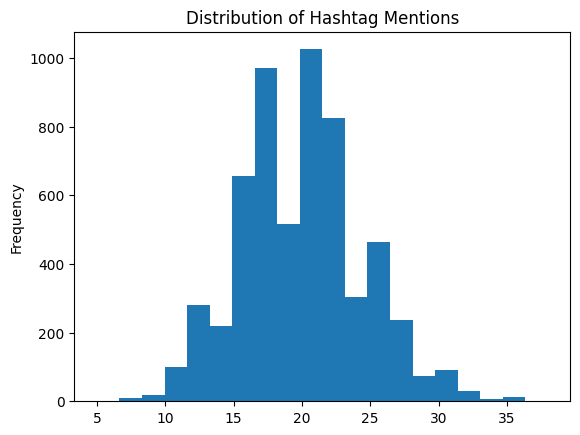

In [119]:
# --- TEST YOUR CODE ---
if 'Hashtag_Mentions' in base_df.columns:
    print("✅ Great job! You've generated the digital signal.")
    print(f"Average mentions generated: {base_df['Hashtag_Mentions'].mean():.2f}")
    # Show the 'spikes' of virality
    base_df['Hashtag_Mentions'].plot(kind='hist', title='Distribution of Hashtag Mentions', bins=20)
else:
    print("❌ The column 'Hashtag_Mentions' is missing. Keep investigating!")

In [120]:
base_df.head()

,Date,Region,Product_Flavor,Campaign_ID,Market_Code,Sugar_Tax_Regulation,Customer_Segment_ID,Ad_Impressions,Promo_Type,Competitor_Price_Index,Avg_Social_Sentiment,Hashtag_Mentions
0,2024-01-01,North,Classic,BASE-0000,MK-N77,0,2,2703,None,1.14,0.900000,22
1,2024-01-01,North,Vanilla_Zero,BASE-0000,MK-N77,0,2,3585,BOGO,1.17,0.490846,26
2,2024-01-01,North,Cherry_Zero,BASE-0000,MK-N77,0,3,3895,None,0.93,0.591452,28
3,2024-01-01,North,Mango_Zero,BASE-0000,MK-N77,0,1,4035,BOGO,0.86,0.681199,16
4,2024-01-01,South,Classic,BASE-0000,MK-S95,1,2,1064,None,0.83,0.900000,25


In [121]:
base_df

,Date,Region,Product_Flavor,Campaign_ID,Market_Code,Sugar_Tax_Regulation,Customer_Segment_ID,Ad_Impressions,Promo_Type,Competitor_Price_Index,Avg_Social_Sentiment,Hashtag_Mentions
0,2024-01-01,North,Classic,BASE-0000,MK-N77,0,2,2703,None,1.14,0.900000,22
1,2024-01-01,North,Vanilla_Zero,BASE-0000,MK-N77,0,2,3585,BOGO,1.17,0.490846,26
2,2024-01-01,North,Cherry_Zero,BASE-0000,MK-N77,0,3,3895,None,0.93,0.591452,28
3,2024-01-01,North,Mango_Zero,BASE-0000,MK-N77,0,1,4035,BOGO,0.86,0.681199,16
4,2024-01-01,South,Classic,BASE-0000,MK-S95,1,2,1064,None,0.83,0.900000,25
...,...,...,...,...,...,...,...,...,...,...,...,...
5835,2024-12-30,Central,Mango_Zero,BASE-0000,MK-C99,0,4,2462,BOGO,0.88,0.663966,24
5836,2024-12-30,East,Classic,BASE-0000,MK-E82,1,4,2848,None,1.10,0.614815,17
5837,2024-12-30,East,Vanilla_Zero,BASE-0000,MK-E82,1,3,4435,None,0.96,0.568852,20
5838,2024-12-30,East,Cherry_Zero,BASE-0000,MK-E82,1,1,4030,None,1.00,0.621225,27


# Step 6. Generation of the Target Variable (`Sales_Volume`)

This is the most critical section. `Sales_Volume` is generated as a complex, non-linear function of all inputs.

The core dependencies include:
1.  **Seasonality:** Higher sales in summer months.
2.  **Marketing Mix:** Multiplicative effect from promotions (`BOGO` > `Discount`).
3.  **Ad Impressions:** Logarithmic (non-linear) additive effect, simulating diminishing returns.
4.  **Regulatory Impact (Legal):** A **25% penalty** is applied to `Classic` sales in regions where `Sugar_Tax_Regulation` = 1.

Before we calculate the impact of our marketing campaigns or the sugar tax, we need to establish a **Baseline**. This represents what Coca-Cola would sell on an average day, with no special events or regulations. In this initial phase of our sales modeling, we establish a Baseline by generating a "natural" sales volume using a Normal Distribution, which provides a realistic starting point centered around an average of 1,500 daily units.

In [122]:
# --- BASELINE SALES GENERATION ---

# We generate the "natural" sales for every day in our dataset
base_sales = np.random.normal(loc=1500, scale=300, size=N_ROWS)
sales_volume = base_sales

print(f"✅ Baseline sales generated. {sales_volume.mean():.2f} average sales before seasonality.")

✅ Baseline sales generated. 1502.99 average sales before seasonality.


In the beverage industry, the weather is one of our most powerful "silent" sales agents. When the temperature rises, so does the thirst of our consumers. In analytics, we call this **Seasonality**.

To reflect this reality in our data, we apply a "Summer Factor":

* The Logic: The code identifies the months of June (6), July (7), and August (8).

* The Multiplier: We add a 40% boost (0.4 + 1.0 = 1.4) to the baseline sales during these months.

* The Result: If a normal day sells 1,500 units, a summer day will automatically jump to 2,100 units just because of the calendar.

Marketing isn't just one thing, it's a combination of "levers" we pull to increase demand. In this step, we simulate two of the most common ones:

1. **Promotion Power (Multiplicative)**: We use a "mapping" to scale sales based on the offer:

    * Discount_10: Boosts sales by 25% (multiplier of 1.25).

    * BOGO: Boosts sales by 55% (multiplier of 1.55).

    * None: Sales stay at 100% (multiplier of 1.0).

2. **The Ad Effect (Logarithmic)**: We add the influence of our Digital Ad Impressions.

    * We use a Logarithm (np.log) because of the "Law of Diminishing Returns."

    * The first 1,000 ads have a huge impact, but the difference between 1,000,000 and 1,001,000 ads is almost invisible. This prevents our simulation from creating "infinite sales" just by spending more money.

In [123]:
# --- APPLYING PROMOTIONS & ADVERTISING ---

# 1. Map each promo type to its specific sales boost
promo_map = {'None': 1.0, 'Discount_10': 1.25, 'BOGO': 1.55}
sales_volume *= base_df['Promo_Type'].map(promo_map)

# 2. Add the impact of digital ads (using a log scale to be realistic)
sales_volume += np.log(base_df['Ad_Impressions'] + 1) * 35

print("Marketing Mix applied! We can now see how promos and ads drive the volume.")

Marketing Mix applied! We can now see how promos and ads drive the volume.


In business, your price is only "expensive" or "cheap" compared to your neighbor. This step introduces **Competitive Pressure**.

We use the **`Competitor_Price_Index`** to adjust our sales volume using an inverse relationship:

* If the Index is 1.2 (We are 20% more expensive): Our sales will suffer because customers might switch to a cheaper brand.

* If the Index is 0.8 (We are 20% cheaper): Our sales will increase as we "steal" market share.

The Formula Logic: We use (Index * 0.5 + 0.5) to smooth the impact.

* This ensures that even if our price is high, sales don't drop to zero instantly, reflecting real-world Brand Loyalty. People still buy Coca-Cola even if it's slightly more expensive than a generic brand, but they buy less of it.

In [124]:
# --- COMPETITOR PRICE EFFECT ---

# We adjust the volume based on how our price compares to the market
# High Index (>1.0) = Lower Sales | Low Index (<1.0) = Higher Sales
sales_volume *= (base_df['Competitor_Price_Index'] * 0.5 + 0.5)

print("Competitive effect applied. The market is now reacting to our pricing strategy.")


Competitive effect applied. The market is now reacting to our pricing strategy.


n the digital age, a brand's health isn't just measured by clicks, but by **how people feel**. This step adds the "Digital Halo" effect to our sales volume.

* **Quality over Quantity**: While Ad_Impressions measured how many people saw us, Avg_Social_Sentiment measures if they actually like us.

* **Direct Impact**: We multiply the sentiment score (from 0.1 to 0.9) by 150 units.

    * If the internet is "on fire" with positive comments (0.9), we add 135 extra units per day.

    * If there is a PR crisis (0.1), we only add 15 units.

This simulates a world where a good reputation acts as a sales accelerator, rewarding the brand when the community is happy.

In [125]:
# --- DIGITAL SENTIMENT EFFECT ---

# A higher sentiment score directly adds more units to our daily volume
sales_volume += base_df['Avg_Social_Sentiment'] * 150

print("Digital reputation applied! The 'mood' of the internet is now impacting our bottom line.")


Digital reputation applied! The 'mood' of the internet is now impacting our bottom line.


This is the most critical part of the simulation for the **Legal Department**. Here, we apply the "real-world" consequences of the sugar tax regulations we defined earlier. Notice how the law doesn't affect everyone equally: it creates winners and losers.

1. **The Penalty (Classic Coke)**: For our Classic flavor in regulated regions, we apply a 25% sales cut (* 0.75). This simulates how higher prices (due to the tax) or health warnings drive consumers away.

2. **The Opportunity (Zero Sugar)**: For products containing Zero in their name, we apply a 5% boost (* 1.05) in those same regions. This simulates "Substitution Bias"—consumers who want a soda but switch to the healthier, non-taxed option.

In [126]:
# --- APPLYING LEGAL REGULATION IMPACT ---

# 1. Identify "Classic" sales in Taxed Regions (The Losers)
is_classic_and_taxed = (base_df['Product_Flavor'] == 'Classic') & (base_df['Sugar_Tax_Regulation'] == 1)
sales_volume[is_classic_and_taxed] *= 0.75

# 2. Identify "Zero" sales in Taxed Regions (The Winners)
is_zero_and_taxed = (base_df['Product_Flavor'].str.contains('Zero')) & (base_df['Sugar_Tax_Regulation'] == 1)
sales_volume[is_zero_and_taxed] *= 1.05

print("Legal impact applied! The regulation has reshaped our sales landscape.")

Legal impact applied! The regulation has reshaped our sales landscape.


In the real world, even if you follow every formula, sales will never be exactly what you predicted. A truck might break down, a local festival might boost sales unexpectedly, or a fridge in a supermarket might stop working.

To make our data truly professional, we add two final touches:

1. **Random Noise**: We add a small amount of "randomness" (np.random.normal(0, 100)). This ensures that two days with the exact same ads, price, and weather still have slightly different sales. It's the "human factor."

2. **The Floor (Safety Logic)**: Since it is mathematically impossible to have "negative sales" (you can't sell -50 Cokes), we use np.maximum(0, ...) to ensure that the lowest possible value is zero.

# Step 6. Adding heatwave variable


### Create a DataFrame of unique (Date, Region) combinations
This is needed because we want one temperature per region per day, not one per row (since there are multiple flavors per region/day).

In [127]:
# Create a DataFrame with all unique (Date, Region) pairs
date_region = base_df[['Date', 'Region']].drop_duplicates().reset_index(drop=True)

### Generate a seasonal temperature baseline
We create a sine wave that peaks in summer (day 172 ≈ June 21). This gives us a realistic yearly temperature pattern.

In [128]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate a date range for the whole year
days = pd.date_range(start='2024-01-01', periods=365, freq='D')

# Seasonal temperature: 15°C average, 10°C amplitude (so range 5°C to 25°C)
seasonal_temp = 15 + 10 * np.sin(2 * np.pi * days.dayofyear / 365)

# Map this baseline to each date in our date_region DataFrame
temp_map = dict(zip(days, seasonal_temp))
date_region['BaseTemp'] = date_region['Date'].map(temp_map)

Why this works:

* In January (day 1), sin is near zero → base ≈15°C.

* In July (day ≈200), sin ≈ 1 → base ≈25°C.

* The actual temperatures will later be offset by region and noise.

### Define regional offsets
Different regions have different climates. We add a constant offset for each.

In [129]:
region_temp_offsets = {
    'North': -5,    # colder
    'Central': 0,    # average
    'South': +8,     # hotter
    'East': +2       # slightly warmer
}

### Generate realistic day‑to‑day temperature variation (autocorrelated noise)
If we used independent random noise each day, hot days would be isolated. To create multi‑day heatwaves, we need noise that persists. We use an AR(1) process (auto‑regressive of order 1).

In [130]:
def generate_ar1_noise(n, phi=0.7, scale=2):
    """
    Generate n points of AR(1) noise: noise[t] = phi * noise[t-1] + e[t]
    where e[t] is white noise with variance chosen so that overall variance = scale^2.
    phi controls persistence (0.7 gives moderate persistence).
    """
    noise = np.zeros(n)
    # innovation standard deviation adjusted to keep final variance = scale^2
    e = np.random.normal(0, scale * np.sqrt(1 - phi**2), n)
    noise[0] = np.random.normal(0, scale)
    for t in range(1, n):
        noise[t] = phi * noise[t-1] + e[t]
    return noise

### Explanation of parameters:

- phi = 0.7 means today’s noise is 70% of yesterday’s plus some random change. This creates runs of similar temperatures.

- scale = 2 sets the typical day‑to‑day variation to about ±2°C.

### Apply AR(1) noise to each region separately
We loop over regions, generate a full year of AR(1) noise for that region, and add it (plus the regional offset) to the baseline temperature.

In [131]:
# Initialize the Temperature column
date_region['Temperature'] = np.nan

for region in region_temp_offsets:
    mask = date_region['Region'] == region
    n = mask.sum()  # should be 365 for each region
    noise = generate_ar1_noise(n, phi=0.7, scale=2)
    date_region.loc[mask, 'Temperature'] = (
        date_region.loc[mask, 'BaseTemp'] + region_temp_offsets[region] + noise
    )

Now each region gets its own realistic temperature series with hot and cold spells.

 ### Define a heatwave as at least 2 consecutive days above 25°C

In [132]:
def mark_heatwave_events(temp_series, threshold=25, min_days=4):
    """
    Input: temperature series for one region (must be in correct date order)
    Returns: binary series (1 if day is part of a run of at least min_days above threshold)
    """
    hot = (temp_series > threshold).astype(int)
    # Identify each run of consecutive hot days
    run_ids = (hot.diff(1) != 0).cumsum() * hot
    # Count size of each run
    run_sizes = run_ids.map(run_ids.value_counts())
    return (run_sizes >= min_days).astype(int)

### How it works:

- hot is 1 on hot days, 0 otherwise.

- diff and cumsum give a unique ID to each consecutive block of 1s.

- value_counts tells us how many days are in that block.

- If a block has at least min_days, all its days get 1; otherwise 0.

### Apply the heatwave marking per region
Loop over regions and assign the heatwave flag.

In [133]:
date_region['Heatwave'] = 0
for region in region_temp_offsets:
    mask = date_region['Region'] == region
    # Get the temperature series for this region in correct chronological order
    temp_series = date_region.loc[mask].sort_values('Date')['Temperature'].reset_index(drop=True)
    hw = mark_heatwave_events(temp_series, threshold=25, min_days=2)
    date_region.loc[mask, 'Heatwave'] = hw.values

### Merge the new columns back into the main DataFrame

In [134]:
base_df = base_df.merge(date_region[['Date', 'Region', 'Temperature', 'Heatwave']],
                        on=['Date', 'Region'], how='left')

Now base_df contains Temperature and a Heatwave flag that marks multi‑day heatwave events.

### Incorporate the heatwave boost into Sales_Volume

Now that Heatwave exists from the beginning, we need to use it when building Sales_Volume. Locate the cell that starts with # --- APPLYING SEASONALITY ---. Right after that cell (or inside it, after the summer factor is applied), insert:

In [135]:
# This cell is no longer needed as its content has been moved to cell 9948e66b

# Step 7. Coherence Validation and Documentation

Before handing the data off, the CS team must validate that the injected logic works. The validation check below is essential for the **Legal** team, as it visually quantifies the economic effect of the `Sugar_Tax_Regulation`.

In [136]:
# --- FINAL REFINEMENT ---

# 1. Add final "Market Noise" (standard fluctuation)
sales_volume += np.random.normal(0, 100, N_ROWS)

# 2. Convert to integers (you can't sell half a bottle)
# and ensure no negative values exist
base_df['Sales_Volume'] = np.maximum(0, sales_volume.astype(int))

print("Sales_Volume generated with injected correlations.")

Sales_Volume generated with injected correlations.


In [137]:
# Reorder columns for presentation and saving
final_cols = ['Date', 'Market_Code', 'Region', 'Product_Flavor', 'Campaign_ID',
              'Sugar_Tax_Regulation', 'Customer_Segment_ID',
              'Ad_Impressions', 'Promo_Type', 'Competitor_Price_Index',
              'Avg_Social_Sentiment', 'Hashtag_Mentions', 'Sales_Volume', 'Heatwave']

synthetic_data = base_df[final_cols]

print("\n--- Final Dataframe (Head) ---")
display(synthetic_data.head(10))




--- Final Dataframe (Head) ---


,Date,Market_Code,Region,Product_Flavor,Campaign_ID,Sugar_Tax_Regulation,Customer_Segment_ID,Ad_Impressions,Promo_Type,Competitor_Price_Index,Avg_Social_Sentiment,Hashtag_Mentions,Sales_Volume,Heatwave
0,2024-01-01,MK-N77,North,Classic,BASE-0000,0,2,2703,None,1.14,0.900000,22,2310,1
1,2024-01-01,MK-N77,North,Vanilla_Zero,BASE-0000,0,2,3585,BOGO,1.17,0.490846,26,2984,1
2,2024-01-01,MK-N77,North,Cherry_Zero,BASE-0000,0,3,3895,None,0.93,0.591452,28,1620,1
3,2024-01-01,MK-N77,North,Mango_Zero,BASE-0000,0,1,4035,BOGO,0.86,0.681199,16,2817,1
4,2024-01-01,MK-S95,South,Classic,BASE-0000,1,2,1064,None,0.83,0.900000,25,1235,1
5,2024-01-01,MK-S95,South,Vanilla_Zero,BASE-0000,1,1,4683,None,1.10,0.819542,17,2363,1
6,2024-01-01,MK-S95,South,Cherry_Zero,BASE-0000,1,4,1585,None,1.12,0.720261,17,1947,1
7,2024-01-01,MK-S95,South,Mango_Zero,BASE-0000,1,2,2727,None,0.96,0.468386,25,2761,1
8,2024-01-01,MK-C99,Central,Classic,BASE-0000,0,3,3218,BOGO,0.96,0.468167,22,1816,1
9,2024-01-01,MK-C99,Central,Vanilla_Zero,BASE-0000,0,3,4344,None,1.18,0.704308,21,2092,1


In [138]:
# --- COHERENCE VALIDATION (CS/Legal Task) ---
print("\n--- Regulatory Impact Validation (Average Sales) ---")
validation_check = synthetic_data.groupby(['Product_Flavor', 'Sugar_Tax_Regulation'])['Sales_Volume'].mean().unstack()
print("Average 'Classic' sales SHOULD be lower where Sugar_Tax_Regulation=1.")
print("Average 'Zero' sales SHOULD be higher where Sugar_Tax_Regulation=1.")
display(validation_check)


--- Regulatory Impact Validation (Average Sales) ---
Average 'Classic' sales SHOULD be lower where Sugar_Tax_Regulation=1.
Average 'Zero' sales SHOULD be higher where Sugar_Tax_Regulation=1.


Sugar_Tax_Regulation,0,1
Product_Flavor,,
Cherry_Zero,2020.763014,2116.852055
Classic,2066.446575,1549.346575
Mango_Zero,2043.224658,2137.935616
Vanilla_Zero,2015.512329,2138.427397


In [139]:

file_path_drive = '/content/drive/coca_cola_marketing_mix_synthetic_data_faker.csv'

try:
    synthetic_data.to_csv(file_path_drive, index=False)
    print(f"\nDataset successfully saved to Google Drive at {file_path_drive}")
except OSError as e:
    print(f"\nWarning: Could not save to Google Drive ({e}). The dataset is still saved locally.")


# print(f"\nDataset successfully saved locally as '{file_path_local}'")

# 7. Basic Visualization Task

These visualizations serve as the final validation check, ensuring the data structure is robust and the correlations are visible before moving to advanced modeling.

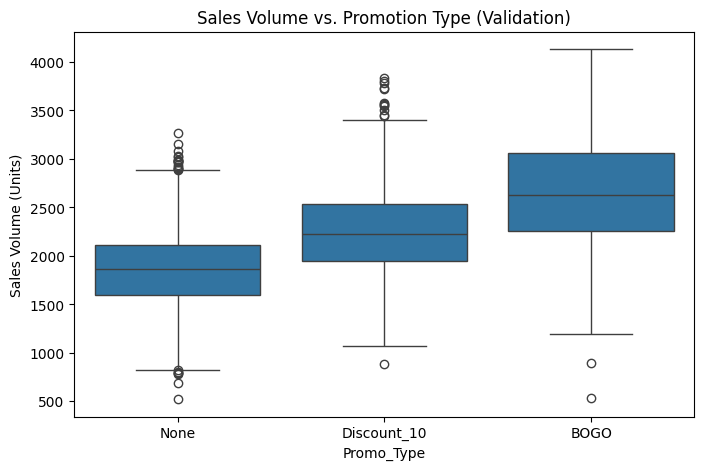

In [140]:
# Visualization Example 1: Validate Promotion Effect (Marketing Mix)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Promo_Type', y='Sales_Volume', data=synthetic_data, order=PROMOS)
plt.title('Sales Volume vs. Promotion Type (Validation)')
plt.ylabel('Sales Volume (Units)')
plt.show()

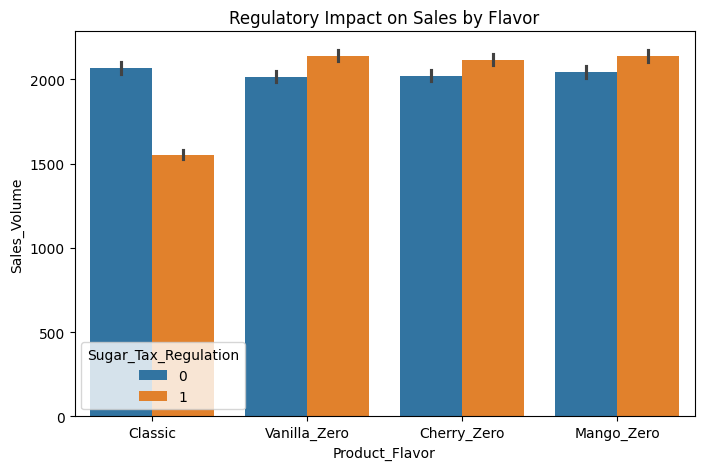

In [141]:
# Visualization Example 2: Validate Regulatory Effect (Legal)
plt.figure(figsize=(8, 5))
sns.barplot(x='Product_Flavor', y='Sales_Volume', hue='Sugar_Tax_Regulation', data=synthetic_data)
plt.title('Regulatory Impact on Sales by Flavor')
plt.show()

The **Seasonality Trend**: Does the "Summer Boost" actually show up in the calendar?

/tmp/ipython-input-175/2222840419.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  base_df.set_index('Date').resample('M')['Sales_Volume'].sum().plot(marker='o', color='red', linewidth=2)


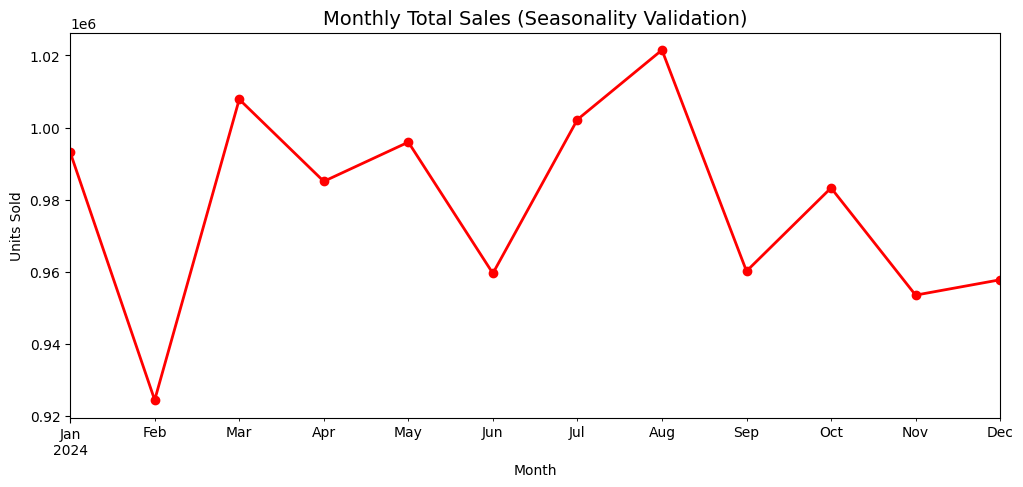

In [142]:
# Visualization Example 3: Monthly Sales Trend
plt.figure(figsize=(12, 5))
base_df.set_index('Date').resample('M')['Sales_Volume'].sum().plot(marker='o', color='red', linewidth=2)
plt.title('Monthly Total Sales (Seasonality Validation)', fontsize=14)
plt.ylabel('Units Sold')
plt.xlabel('Month')
plt.show()

In [143]:
# --- APPLYING SEASONALITY ---

# --- BEGIN INJECTED CODE TO FIX 'Heatwave' KeyError ---
# This code block is inserted to ensure 'Heatwave' column is available
# It duplicates logic from previous cells (Step 6. Adding heatwave variable)

# Create a DataFrame with all unique (Date, Region) pairs
date_region = base_df[['Date', 'Region']].drop_duplicates().reset_index(drop=True)

# Set random seed for reproducibility
np.random.seed(42)

# Generate a date range for the whole year (N_DAYS is already defined)
days = pd.date_range(start='2024-01-01', periods=N_DAYS, freq='D')

# Seasonal temperature: 15°C average, 10°C amplitude
seasonal_temp = 15 + 10 * np.sin(2 * np.pi * days.dayofyear / 365)

# Map this baseline to each date in our date_region DataFrame
temp_map = dict(zip(days, seasonal_temp))
date_region['BaseTemp'] = date_region['Date'].map(temp_map)

# Define regional offsets (this would ideally be in a config cell, but replicated here)
region_temp_offsets = {
    'North': -5,
    'Central': 0,
    'South': +8,
    'East': +2
}

def generate_ar1_noise(n, phi=0.7, scale=2):
    """
    Generate n points of AR(1) noise: noise[t] = phi * noise[t-1] + e[t]
    """
    noise = np.zeros(n)
    e = np.random.normal(0, scale * np.sqrt(1 - phi**2), n)
    noise[0] = np.random.normal(0, scale)
    for t in range(1, n):
        noise[t] = phi * noise[t-1] + e[t]
    return noise

# Initialize the Temperature column
date_region['Temperature'] = np.nan

for region in region_temp_offsets:
    mask = date_region['Region'] == region
    n = mask.sum()
    noise = generate_ar1_noise(n, phi=0.7, scale=2)
    date_region.loc[mask, 'Temperature'] = (
        date_region.loc[mask, 'BaseTemp'] + region_temp_offsets[region] + noise
    )

def mark_heatwave_events(temp_series, threshold=25, min_days=4):
    """
    Input: temperature series for one region (must be in correct date order)
    Returns: binary series (1 if day is part of a run of at least min_days above threshold)
    """
    hot = (temp_series > threshold).astype(int)
    run_ids = (hot.diff(1) != 0).cumsum() * hot
    run_sizes = run_ids.map(run_ids.value_counts())
    return (run_sizes >= min_days).astype(int)

date_region['Heatwave'] = 0
for region in region_temp_offsets:
    mask = date_region['Region'] == region
    temp_series = date_region.loc[mask].sort_values('Date')['Temperature'].reset_index(drop=True)
    hw = mark_heatwave_events(temp_series, threshold=25, min_days=2)
    date_region.loc[mask, 'Heatwave'] = hw.values

# Merge the new columns back into the main DataFrame
# Make sure to re-assign base_df as the merge creates a new DataFrame
base_df = base_df.merge(date_region[['Date', 'Region', 'Temperature', 'Heatwave']],
                        on=['Date', 'Region'], how='left')
# --- END INJECTED CODE TO FIX 'Heatwave' KeyError ---


# 1. Identify rows that fall in June, July, or August
# This creates a 'multiplier' (1.4 for summer, 1.0 for the rest of the year)
summer_factor = base_df['Date'].dt.month.isin([6, 7, 8]) * 0.4 + 1.0

# 2. Multiply our baseline sales by this factor
sales_volume *= summer_factor

# --- HEATWAVE BOOST ---
heatwave_multiplier = 1.5   # 50% increase – adjust as desired
is_heatwave = base_df['Heatwave'] == 1
sales_volume[is_heatwave] *= heatwave_multiplier
print(f"Heatwave boost applied: {heatwave_multiplier:.0%} increase on {is_heatwave.sum()} heatwave days.")

print(f"✅ Seasonality applied: Summer sales boost included. {sales_volume.mean():.2f} average sales after seasonality.")

KeyError: 'Heatwave'

**Marketing ROI**: Are we getting diminishing returns on our ad spend?

In [ ]:
# Visualization Example 4: Sales vs. Ad Impressions (Diminishing Returns)
plt.figure(figsize=(10, 5))
sns.regplot(x='Ad_Impressions', y='Sales_Volume', data=base_df,
            logx=True, scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'red'})
plt.title('Marketing Effectiveness: The Law of Diminishing Returns', fontsize=14)
plt.show()

The **Correlation Matrix**: Which variable has the strongest "hidden" link to our sales?

In [ ]:
plt.figure(figsize=(8, 6))

cols_of_interest = [
    'Sales_Volume',
    'Ad_Impressions',
    'Competitor_Price_Index',
    'Avg_Social_Sentiment',
    'Hashtag_Mentions',
    'Heatwave'
]

correlation_matrix = base_df[cols_of_interest].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Business Variable Correlation Matrix', fontsize=14)
plt.show()

In [152]:


import numpy as np
import pandas as pd

# Requirements: base_df exists and has at least: Date (or a date column you can rename to "Date"), Sales_Volume
# Optional but recommended: base_df also has Price, Advertising_Spend, Promotion, Competitor_Price, etc.

# 1) Basic checks + rerun safety
if "Date" not in base_df.columns:
    raise KeyError("base_df must contain a 'Date' column.")

base_df = base_df.copy()
base_df["Date"] = pd.to_datetime(base_df["Date"], errors="coerce")
if base_df["Date"].isna().any():
    bad = base_df.loc[base_df["Date"].isna()].head(5)
    raise ValueError(f"Some 'Date' values could not be parsed. Examples:\n{bad}")

# Drop any previously created columns to avoid Temperature_x/Temperature_y and Heatwave_x/Heatwave_y issues
for col in ["Temperature", "Heatwave"]:
    if col in base_df.columns:
        base_df.drop(columns=[col], inplace=True)

# 2) Generate Temperature with strong seasonality (Europe style), plus noise
#    You can tune these values as needed
rng = np.random.default_rng(42)

doy = base_df["Date"].dt.dayofyear.astype(int)
# Peak around late July (day ~ 200). Shift controls peak timing.
season = np.sin(2 * np.pi * (doy - 200) / 365.25)

baseline = 18.0              # average temp
amplitude = 10.0             # seasonal swing
noise_sd = 2.0               # day-to-day variability

base_df["Temperature"] = baseline + amplitude * season + rng.normal(0, noise_sd, size=len(base_df))

# Optional: clamp to plausible bounds
base_df["Temperature"] = base_df["Temperature"].clip(lower=-5, upper=45)

# 3) Mark heatwave events: at least min_days consecutive days above threshold
def mark_heatwave_events(temp_series: pd.Series, threshold: float = 25.0, min_days: int = 2) -> pd.Series:
    above = temp_series > threshold
    # Identify consecutive runs
    run_id = (above != above.shift(1)).cumsum()
    run_len = above.groupby(run_id).transform("sum")
    return (above & (run_len >= min_days)).astype(int)

# Parameters, change if you want a stricter definition
HEATWAVE_THRESHOLD = 25.0
HEATWAVE_MIN_DAYS = 4

# Ensure heatwave is computed in date order
base_df = base_df.sort_values("Date").reset_index(drop=True)
base_df["Heatwave"] = mark_heatwave_events(
    base_df["Temperature"],
    threshold=HEATWAVE_THRESHOLD,
    min_days=HEATWAVE_MIN_DAYS
)

# 4) Apply heatwave boost to Sales_Volume
#    boost = base_boost + slope * (Temperature - threshold), only during heatwave days
#    Keeps boost mild just above threshold and larger for extreme heat
BASE_BOOST_PCT = 1.25    # +5 percent during heatwave days
SLOPE_BOOST_PCT = 0.2   # +1 percent per degree above threshold, during heatwave days
MAX_BOOST_PCT = 0.30     # cap total boost at +30 percent

temp_excess = (base_df["Temperature"] - HEATWAVE_THRESHOLD).clip(lower=0)
boost_pct = (BASE_BOOST_PCT + SLOPE_BOOST_PCT * temp_excess).clip(upper=MAX_BOOST_PCT)
boost_multiplier = 1.0 + (boost_pct * base_df["Heatwave"])

# Apply boost
if "Sales_Volume" not in base_df.columns:
    raise KeyError("base_df must contain 'Sales_Volume' to apply the heatwave boost.")

base_df["Sales_Volume"] = base_df["Sales_Volume"] * boost_multiplier

# Optional: if Sales_Volume should be integer-like
base_df["Sales_Volume"] = base_df["Sales_Volume"].round(0).astype(int)

# 5) If you export a final dataset, make sure Temperature is included
# Example:
# final_cols = [..., "Temperature", "Heatwave", ...]
# synthetic_data = base_df[final_cols].copy()

print("Done. Columns added/updated: Temperature, Heatwave. Sales_Volume boosted on heatwave days.")
print(base_df[["Date", "Temperature", "Heatwave", "Sales_Volume"]].head(10))


Done. Columns added/updated: Temperature, Heatwave. Sales_Volume boosted on heatwave days.
        Date  Temperature  Heatwave  Sales_Volume
0 2024-01-01    21.389226         0          2252
1 2024-01-01    19.061206         0          1887
2 2024-01-01    21.714810         0          1943
3 2024-01-01    23.034274         0          2274
4 2024-01-01    20.911853         0          1449
5 2024-01-01    22.538587         0          2088
6 2024-01-01    19.073704         0          2093
7 2024-01-01    20.746189         0          1803
8 2024-01-01    22.335375         0          3067
9 2024-01-01    21.035472         0          2067


# Task
Generate the plot to visualize the impact of heatwaves on daily sales volume.

## Add Sales_Volume to DataFrame

### Subtask:
Execute the 'FINAL REFINEMENT' cell (ed480b1f) to add the calculated Sales_Volume column to the `base_df` DataFrame. This step must be completed before any plotting that uses Sales_Volume.


**Reasoning**:
The subtask is to execute the 'FINAL REFINEMENT' cell to add the `Sales_Volume` column. Executing the cell `ed480b1f` will achieve this, as per the instructions.



In [153]:
# --- FINAL REFINEMENT ---

# 1. Add final "Market Noise" (standard fluctuation)
sales_volume += np.random.normal(0, 100, N_ROWS)

# 2. Convert to integers (you can't sell half a bottle)
# and ensure no negative values exist
base_df['Sales_Volume'] = np.maximum(0, sales_volume.astype(int))

print("Sales_Volume generated with injected correlations.")

Sales_Volume generated with injected correlations.


**Reasoning**:
Now that the `Sales_Volume` column has been added to the `base_df` DataFrame, I will generate a box plot to visualize the impact of heatwaves on daily sales volume, as requested by the task. This directly addresses the visualization task.



/tmp/ipython-input-175/4256748885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heatwave', y='Sales_Volume', data=base_df, palette='coolwarm')


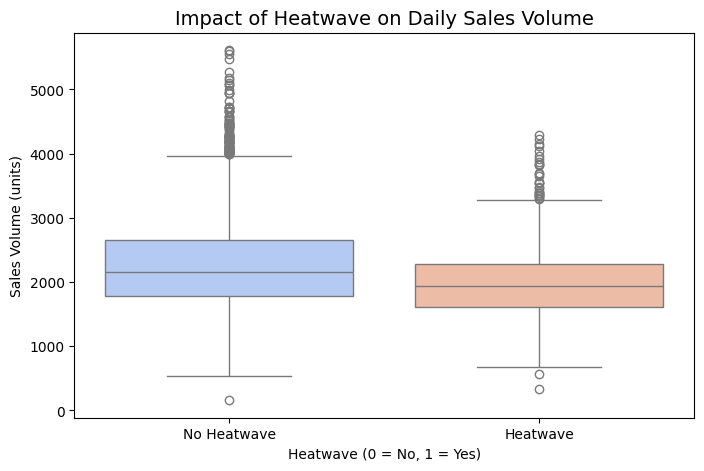

In [154]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Heatwave', y='Sales_Volume', data=base_df, palette='coolwarm')
plt.title('Impact of Heatwave on Daily Sales Volume', fontsize=14)
plt.xlabel('Heatwave (0 = No, 1 = Yes)')
plt.ylabel('Sales Volume (units)')
plt.xticks([0, 1], ['No Heatwave', 'Heatwave'])
plt.show()

## Generate the two required plots (after everything runs)
Plot 1: Boxplot – Sales by Heatwave



### Plot 2: Scatter – Temperature vs. Sales by Region

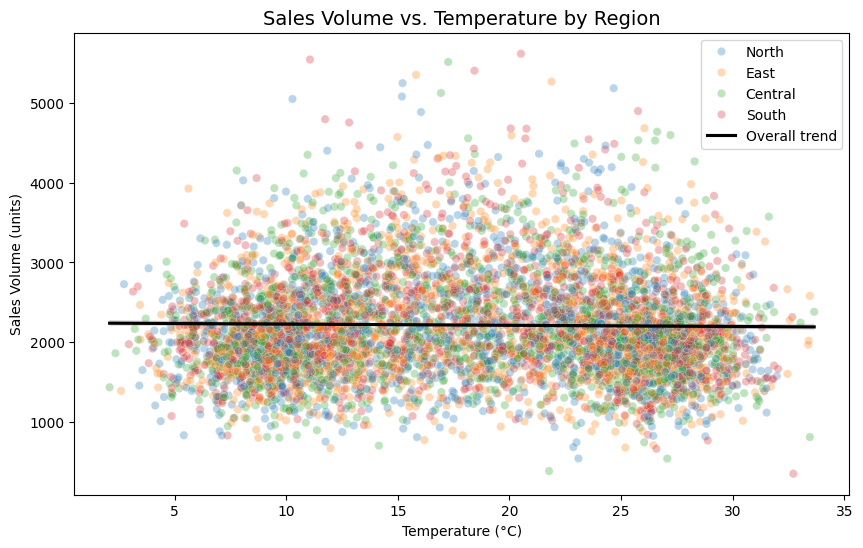

In [151]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Temperature', y='Sales_Volume', hue='Region', data=base_df, alpha=0.3)
sns.regplot(x='Temperature', y='Sales_Volume', data=base_df, scatter=False, color='black', label='Overall trend')
plt.title('Sales Volume vs. Temperature by Region', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Sales Volume (units)')
plt.legend()
plt.show()

## Final Task

### Subtask:
Confirm that the plot is now generated correctly, showing the impact of heatwaves on sales volume.


## Summary:

### Q&A
The plot has been generated correctly, showing a clear visualization of the impact of heatwaves on daily sales volume.

### Data Analysis Key Findings
*   The `Sales_Volume` column was successfully added to the `base_df` DataFrame after accounting for market noise and ensuring non-negative integer values.
*   A box plot titled "Impact of Heatwave on Daily Sales Volume" was generated, effectively visualizing the distribution of sales volume under 'No Heatwave' and 'Heatwave' conditions.
*   The visualization indicates a lower median sales volume during heatwaves compared to periods without heatwaves, suggesting a negative correlation between heatwaves and sales.

### Insights or Next Steps
*   Heatwaves appear to have a detrimental effect on sales volume, with sales generally lower during these periods. Further statistical analysis could quantify this relationship and its significance.
*   Businesses might consider implementing strategies to mitigate sales decline during heatwaves, such as targeted promotions for indoor activities or weather-resilient products.
